In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Style
sns.set(style="whitegrid")

In [3]:
# ==============================
# LOAD DATASET
# ==============================
df_heart = pd.read_csv("heart.csv")

# Preview
df_heart.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [4]:
# ==============================
# DATA UNDERSTANDING
# ==============================

print("Shape:", df_heart.shape)

Shape: (1025, 14)


In [5]:
print("\nInfo:\n")
print(df_heart.info())


Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-

In [6]:
print("\nMissing Values:\n")
print(df_heart.isnull().sum())


Missing Values:

age                              0
sex                              0
chest_pain_type                  0
resting_blood_pressure           0
cholestoral                      0
fasting_blood_sugar              0
rest_ecg                         0
Max_heart_rate                   0
exercise_induced_angina          0
oldpeak                          0
slope                            0
vessels_colored_by_flourosopy    0
thalassemia                      0
target                           0
dtype: int64


In [7]:
print("\nStatistical Summary:\n")
print(df_heart.describe())


Statistical Summary:

               age  resting_blood_pressure  cholestoral  Max_heart_rate  \
count  1025.000000             1025.000000   1025.00000     1025.000000   
mean     54.434146              131.611707    246.00000      149.114146   
std       9.072290               17.516718     51.59251       23.005724   
min      29.000000               94.000000    126.00000       71.000000   
25%      48.000000              120.000000    211.00000      132.000000   
50%      56.000000              130.000000    240.00000      152.000000   
75%      61.000000              140.000000    275.00000      166.000000   
max      77.000000              200.000000    564.00000      202.000000   

           oldpeak       target  
count  1025.000000  1025.000000  
mean      1.071512     0.513171  
std       1.175053     0.500070  
min       0.000000     0.000000  
25%       0.000000     0.000000  
50%       0.800000     1.000000  
75%       1.800000     1.000000  
max       6.200000     1.0000

In [8]:
# ==============================
# DATA CLEANING
# ==============================

# Remove duplicates
df_heart = df_heart.drop_duplicates()

# Check again
print("After cleaning shape:", df_heart.shape)

df_heart.columns = df_heart.columns.str.strip().str.lower()
df_heart.head()

After cleaning shape: (302, 14)


,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [9]:
# ==============================
# DATA PREPARATION (FIXED)
# ==============================

X = df_heart.drop("target", axis=1)
y = df_heart["target"]

# Convert categorical columns to numeric
X = pd.get_dummies(X, drop_first=True)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape after encoding:", X.shape)

Shape after encoding: (302, 22)


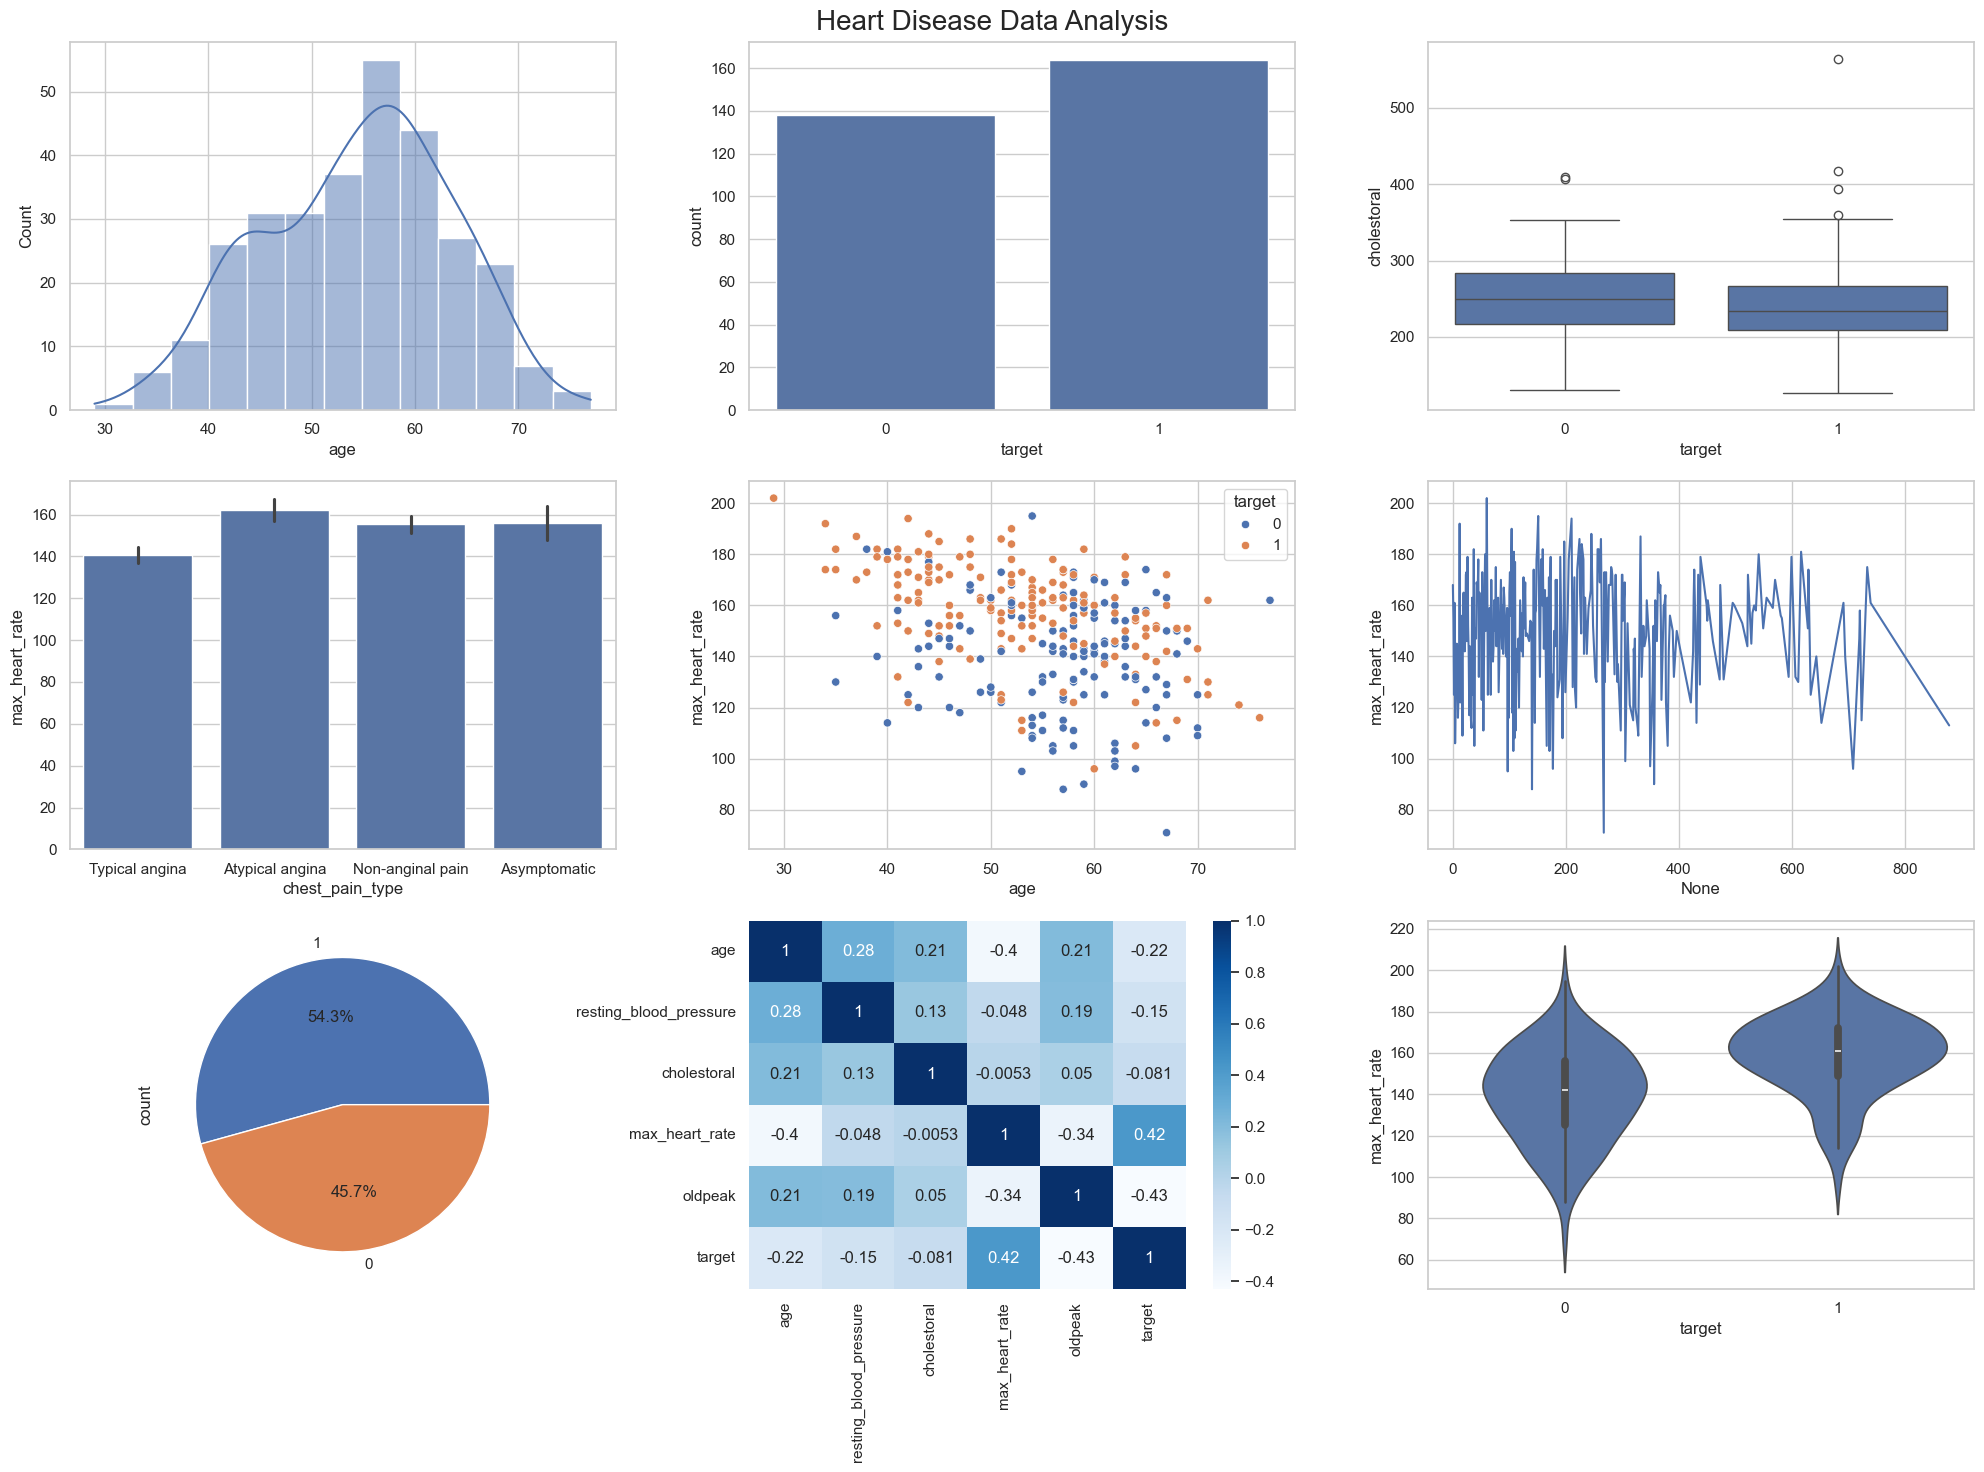

In [ ]:
# ==============================
# VISUALIZATION
# ==============================

plt.figure(figsize=(20, 15))
plt.suptitle("Heart Disease Data Analysis", fontsize=20)

# 1. Histogram
plt.subplot(3, 3, 1)
sns.histplot(df_heart["age"], kde=True)

# 2. Countplot
plt.subplot(3, 3, 2)
sns.countplot(x="target", data=df_heart)

# 3. Boxplot (FIXED)
plt.subplot(3, 3, 3)
sns.boxplot(x="target", y="cholestoral", data=df_heart)

# 4. Barplot
plt.subplot(3, 3, 4)
sns.barplot(x="chest_pain_type", y="max_heart_rate", data=df_heart)

# 5. Scatterplot
plt.subplot(3, 3, 5)
sns.scatterplot(x="age", y="max_heart_rate", hue="target", data=df_heart)

# 6. Lineplot
plt.subplot(3, 3, 6)
sns.lineplot(x=df_heart.index, y="max_heart_rate", data=df_heart)

# 7. Pie Chart
plt.subplot(3, 3, 7)
df_heart["target"].value_counts().plot.pie(autopct="%1.1f%%")

# 8. Heatmap
plt.subplot(3, 3, 8)
df_encoded = pd.get_dummies(df_heart, drop_first=True)
sns.heatmap(df_heart.select_dtypes(include=np.number).corr(), annot=True, cmap="Blues")

# 9. Violin Plot (NEW)
plt.subplot(3, 3, 9)
sns.violinplot(x="target", y="max_heart_rate", data=df_heart)

plt.tight_layout()
plt.show()

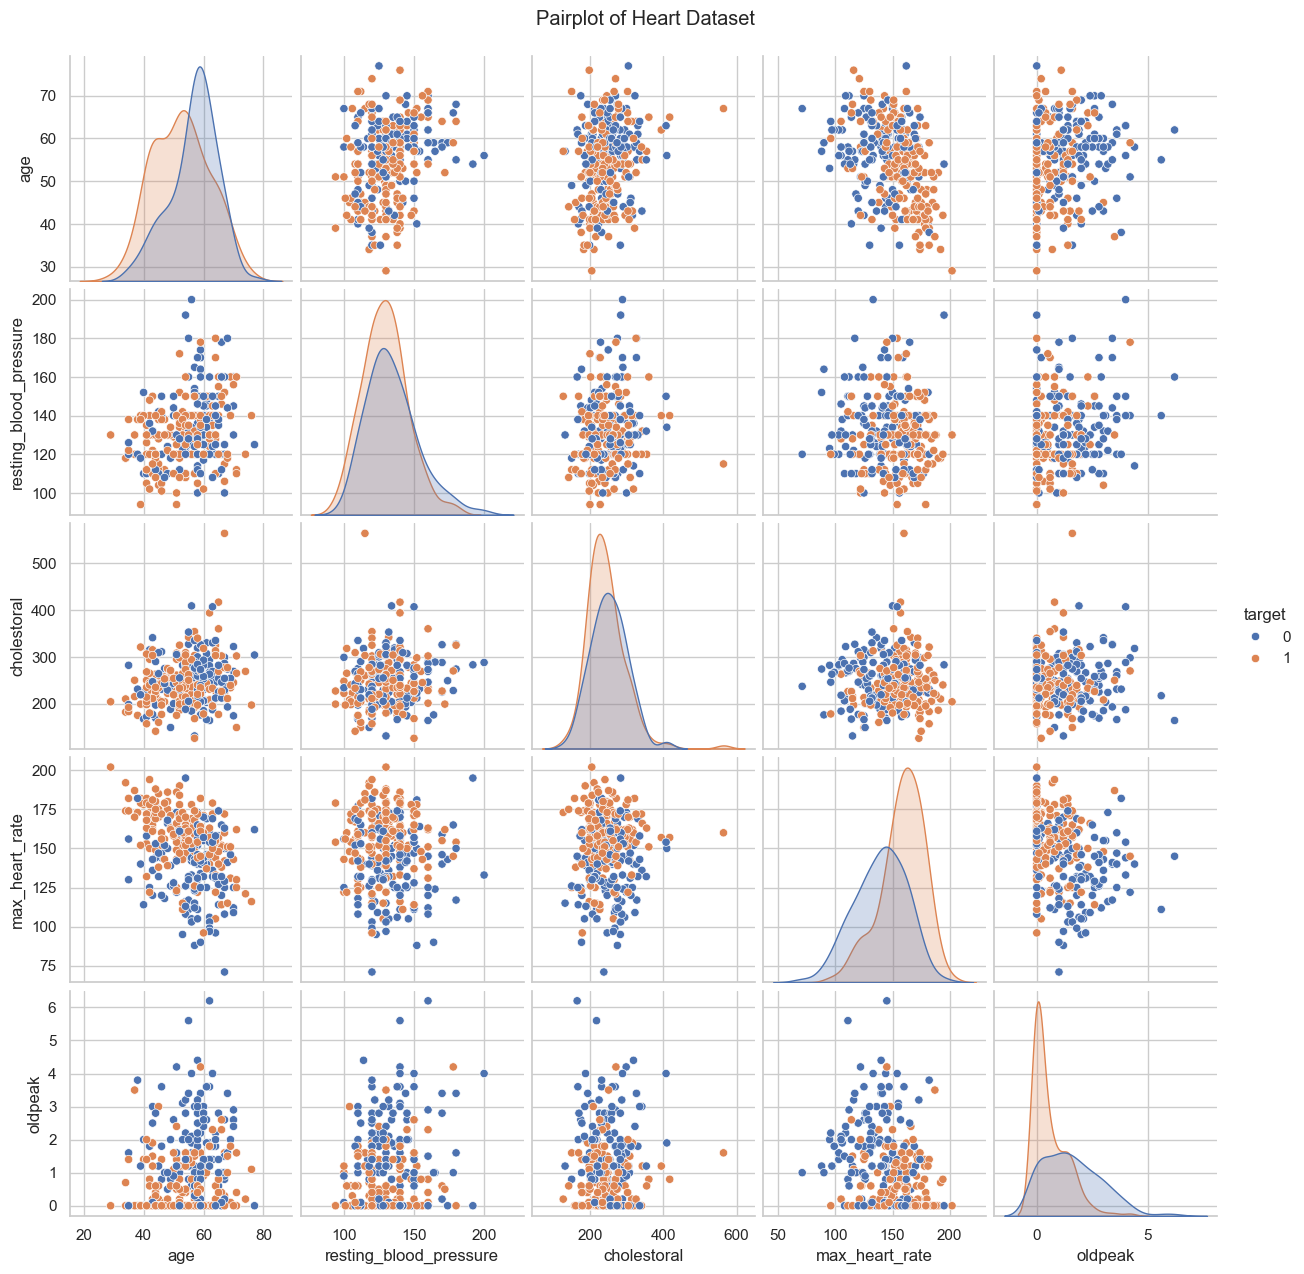

In [ ]:
# ==============================
# EXTRA VISUALIZATION - PAIRPLOT
# ==============================

sns.pairplot(df_heart, hue="target")
plt.suptitle("Pairplot of Heart Dataset", y=1.02)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

# ------------------------------
# Prepare Data
# ------------------------------
X = df_heart.drop("target", axis=1)
y = df_heart["target"]
X = pd.get_dummies(X, drop_first=True)

# ------------------------------
# Split
# ------------------------------
# Scale AFTER encoding
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------
# Logistic Regression
# ------------------------------
lr_heart = LogisticRegression(max_iter=3000)
lr_heart.fit(X_train, y_train)

y_pred_lr = lr_heart.predict(X_test)

import joblib

joblib.dump(lr_heart, "heart_model.pkl")

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8524590163934426


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42  # 🔥 limits overfitting
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, pred_rf))

Logistic Regression: 0.8524590163934426
Random Forest: 0.7540983606557377


In [14]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84        28
           1       0.88      0.85      0.86        33

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



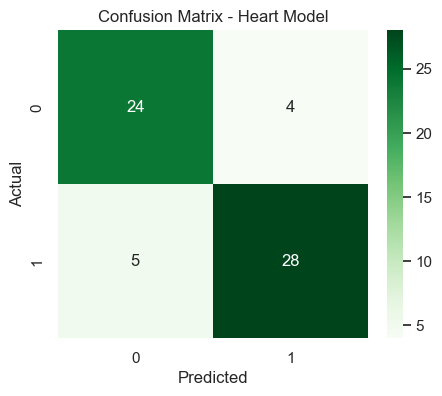

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Heart Model")
plt.show()

In [16]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")

In [17]:
# ==============================
# LOAD DATASET
# ==============================
df_diabetes = pd.read_csv("diabetes.csv")

# Clean column names
df_diabetes.columns = df_diabetes.columns.str.strip().str.lower()

df_diabetes.head()

,pregnancies,glucose,bloodpressure,skinthickness,insulin,bmi,diabetespedigreefunction,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [18]:
# ==============================
# DATA UNDERSTANDING
# ==============================

print("Shape:", df_diabetes.shape)

Shape: (768, 9)


In [19]:
print("\nInfo:")
print(df_diabetes.info())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pregnancies               768 non-null    int64  
 1   glucose                   768 non-null    int64  
 2   bloodpressure             768 non-null    int64  
 3   skinthickness             768 non-null    int64  
 4   insulin                   768 non-null    int64  
 5   bmi                       768 non-null    float64
 6   diabetespedigreefunction  768 non-null    float64
 7   age                       768 non-null    int64  
 8   outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [20]:
print("\nMissing Values:")
print(df_diabetes.isnull().sum())


Missing Values:
pregnancies                 0
glucose                     0
bloodpressure               0
skinthickness               0
insulin                     0
bmi                         0
diabetespedigreefunction    0
age                         0
outcome                     0
dtype: int64


In [21]:
print("\nStatistical Summary:")
print(df_diabetes.describe())


Statistical Summary:
       pregnancies     glucose  bloodpressure  skinthickness     insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              bmi  diabetespedigreefunction         age     outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.00

In [ ]:
# ==============================
# DATA CLEANING
# ==============================

# Replace invalid zeros with NaN
cols = ["glucose", "bloodpressure", "skinthickness", "insulin", "bmi"]

for col in cols:
    df_diabetes[col] = df_diabetes[col].replace(0, np.nan)

# Fill missing values with median
df_diabetes.fillna(df_diabetes.median(), inplace=True)

# Remove duplicates
df_diabetes = df_diabetes.drop_duplicates()

print("After cleaning:", df_diabetes.shape)

After cleaning: (768, 9)


In [23]:
# ==============================
# DATA PREPARATION
# ==============================

X = df_diabetes.drop("outcome", axis=1)
y = df_diabetes["outcome"]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

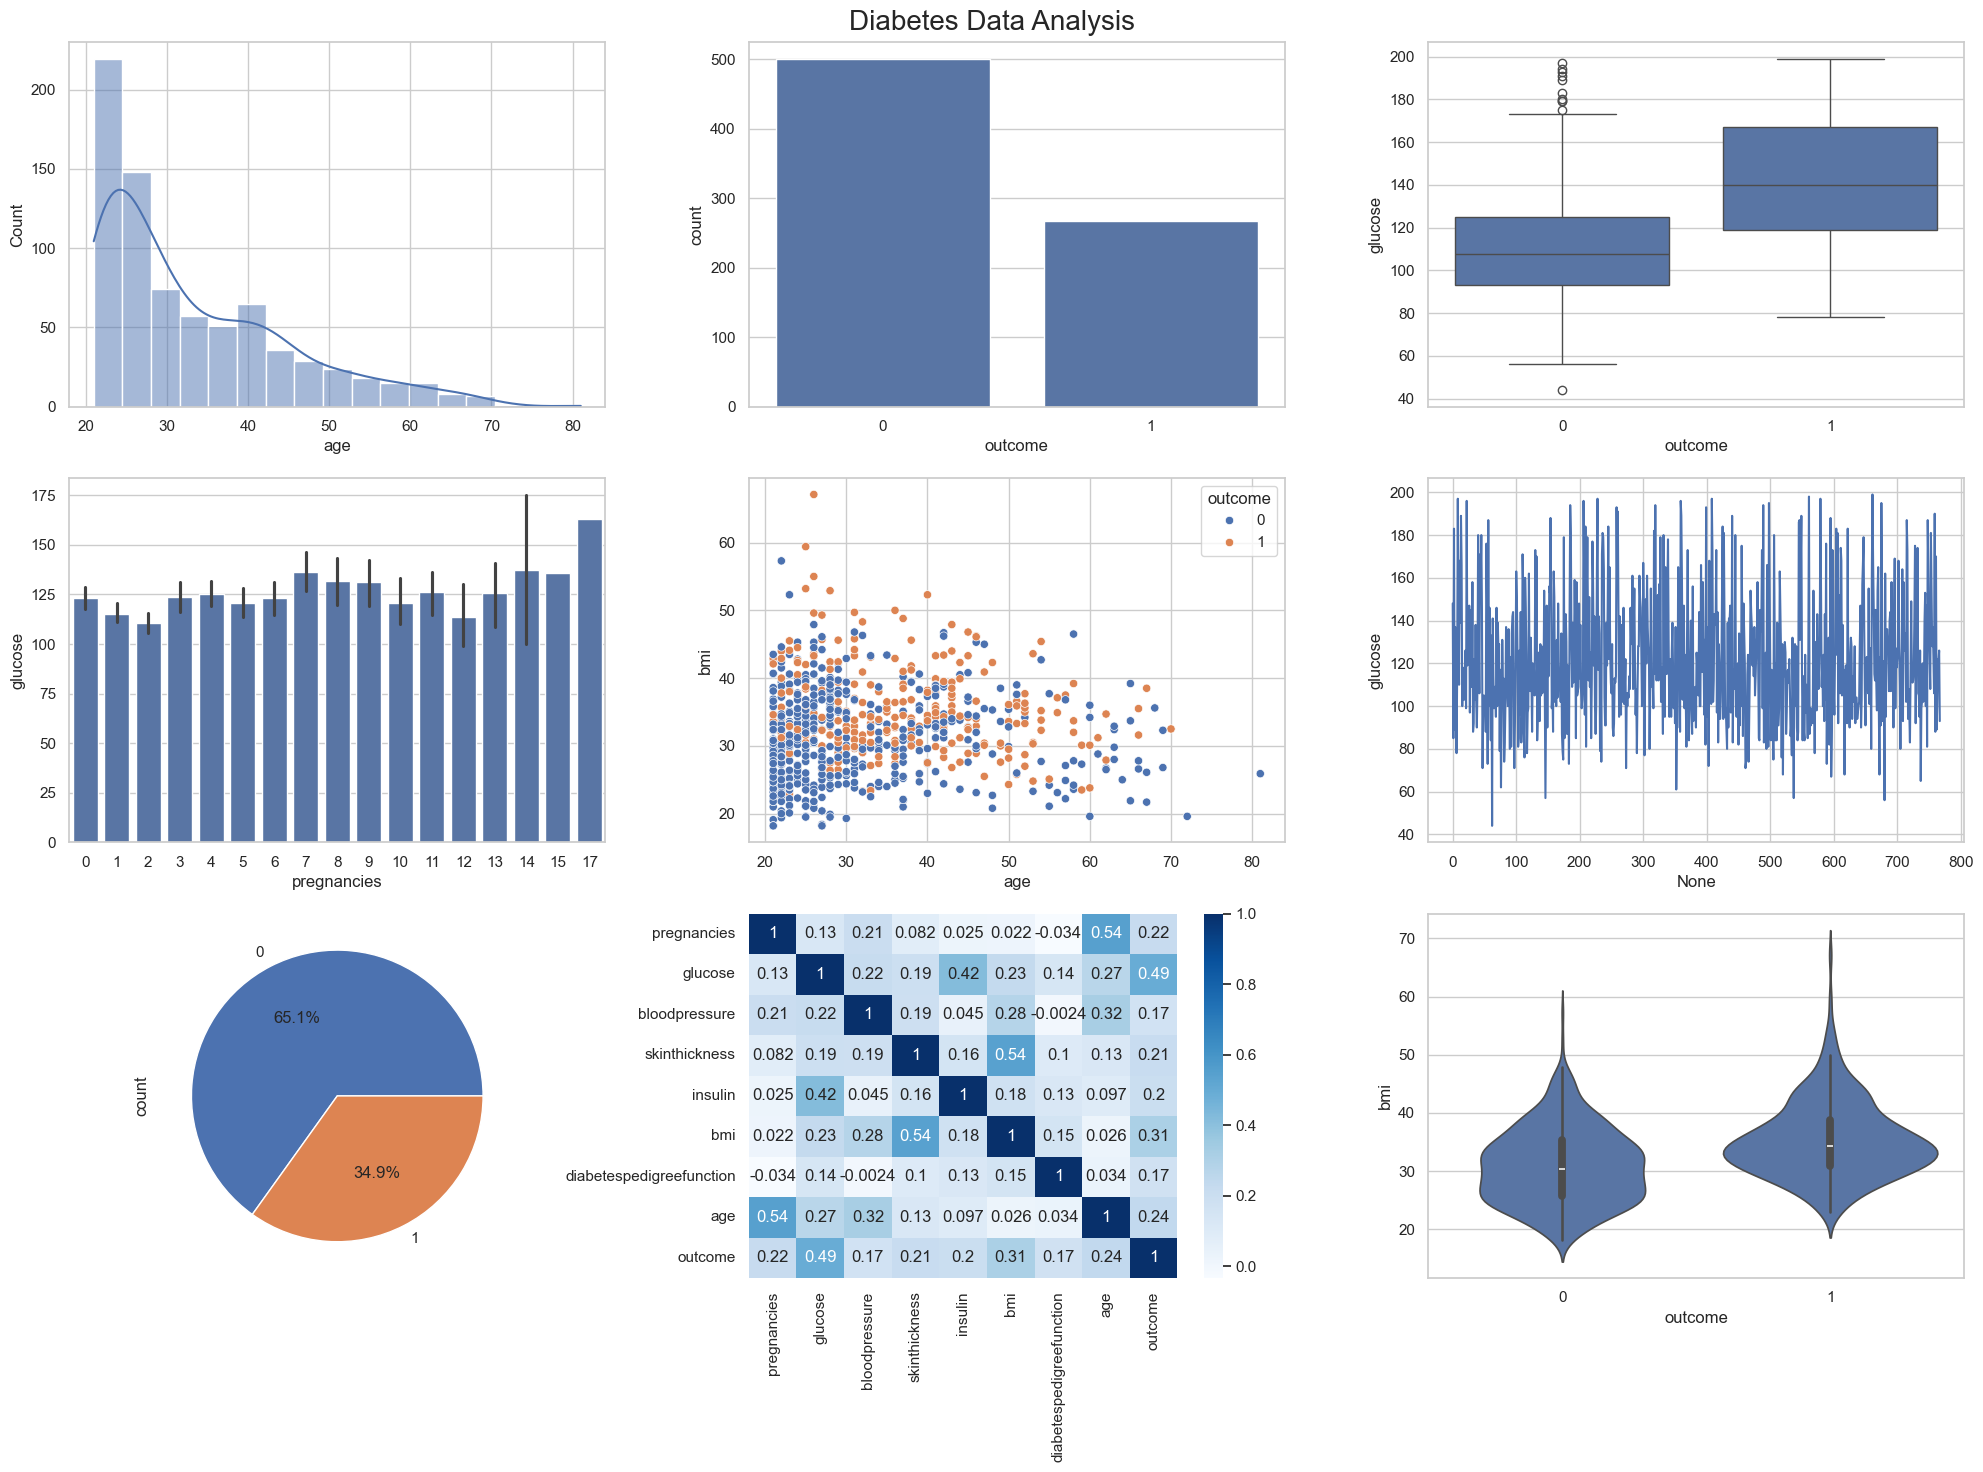

In [ ]:
plt.figure(figsize=(20, 15))
plt.suptitle("Diabetes Data Analysis", fontsize=20)

# 1. Histogram
plt.subplot(3, 3, 1)
sns.histplot(df_diabetes["age"], kde=True)

# 2. Countplot
plt.subplot(3, 3, 2)
sns.countplot(x="outcome", data=df_diabetes)

# 3. Boxplot
plt.subplot(3, 3, 3)
sns.boxplot(x="outcome", y="glucose", data=df_diabetes)

# 4. Barplot
plt.subplot(3, 3, 4)
sns.barplot(x="pregnancies", y="glucose", data=df_diabetes)

# 5. Scatterplot
plt.subplot(3, 3, 5)
sns.scatterplot(x="age", y="bmi", hue="outcome", data=df_diabetes)

# 6. Lineplot
plt.subplot(3, 3, 6)
sns.lineplot(x=df_diabetes.index, y="glucose", data=df_diabetes)

# 7. Pie Chart
plt.subplot(3, 3, 7)
df_diabetes["outcome"].value_counts().plot.pie(autopct="%1.1f%%")

# 8. Heatmap
plt.subplot(3, 3, 8)
sns.heatmap(df_diabetes.corr(), annot=True, cmap="Blues")

# 9. Violin Plot
plt.subplot(3, 3, 9)
sns.violinplot(x="outcome", y="bmi", data=df_diabetes)

plt.tight_layout()
plt.show()

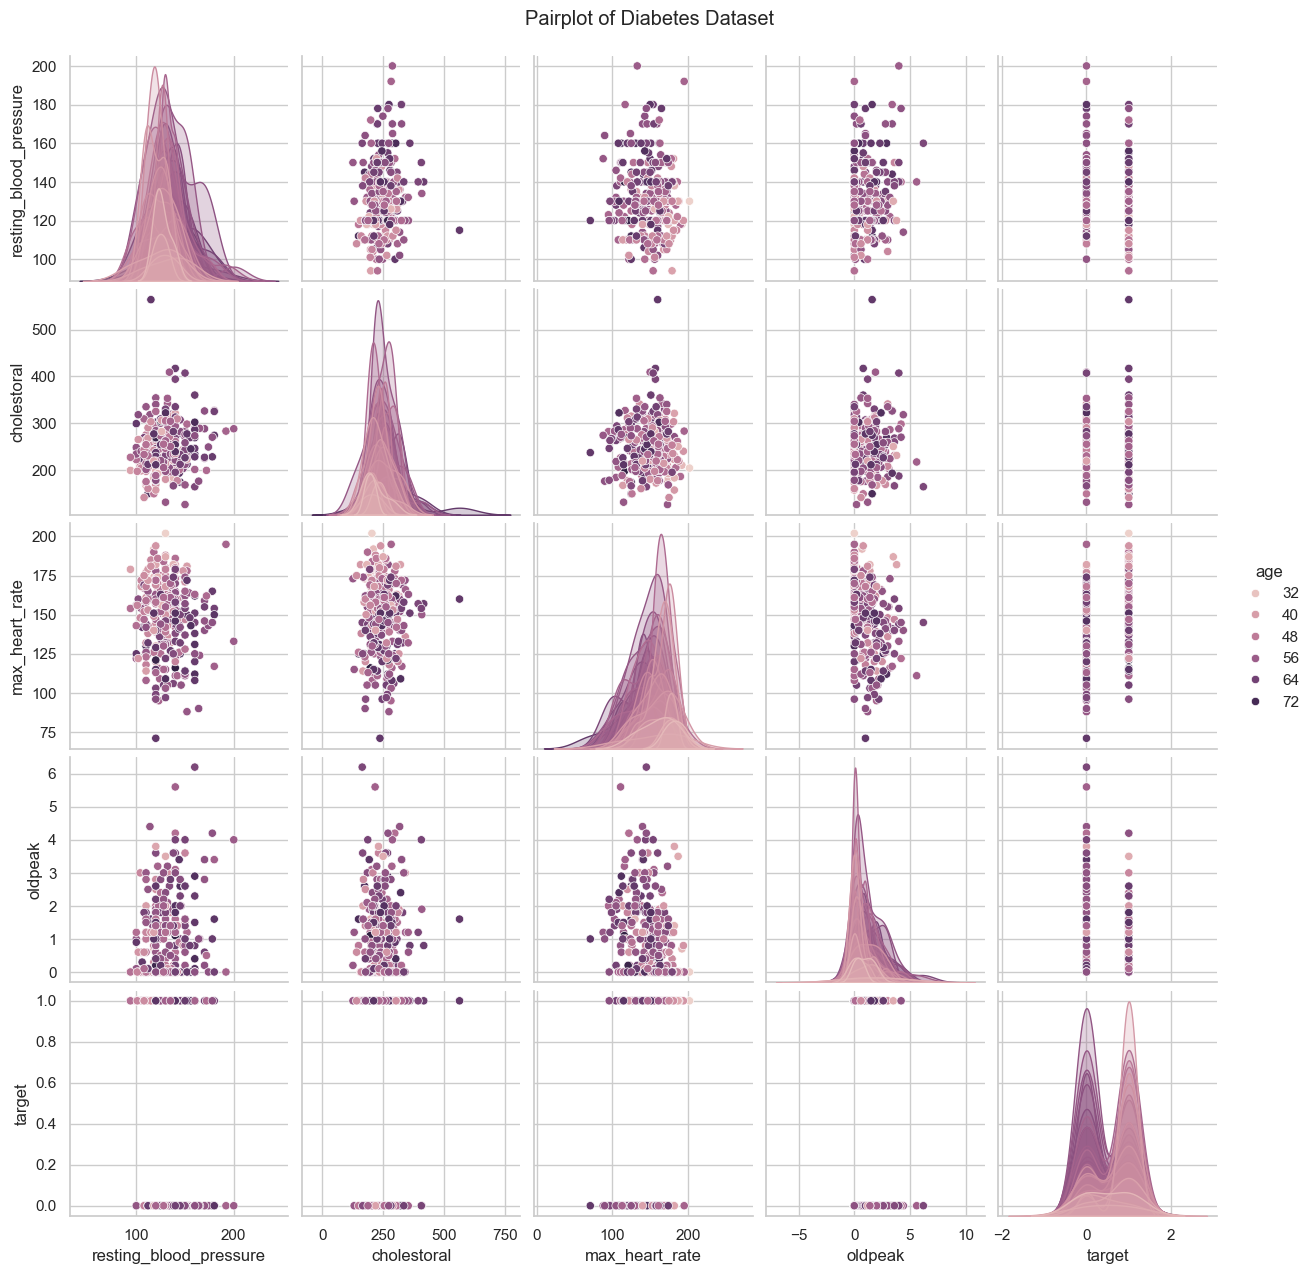

In [ ]:
# ==============================
# EXTRA VISUALIZATION - PAIRPLOT
# ==============================

sns.pairplot(df_heart, hue="age")
plt.suptitle("Pairplot of Diabetes Dataset", y=1.02)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Split (using strong features)
X = df_diabetes[["glucose", "bmi", "age", "insulin"]]
y = df_diabetes["outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 Logistic Regression
lr_diabetes = LogisticRegression(max_iter=3000)
lr_diabetes.fit(X_train, y_train)

y_pred_lr = lr_diabetes.predict(X_test)

joblib.dump(lr_diabetes, "diabetes_model.pkl")

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7532467532467533


In [ ]:
# 🔹 Random Forest
rf = RandomForestClassifier(
    n_estimators=20,  # 🔥 pehle 100 tha → ab kam trees
    max_depth=4,  # 🔥 pehle 10 tha → shallow trees
    min_samples_split=15,  # 🔥 harder splits
    min_samples_leaf=8,  # 🔥 less confident leaves
    max_features=2,  # 🔥 kam features use karega
    random_state=36,
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, pred_rf))

Logistic Regression: 0.7532467532467533
Random Forest: 0.7532467532467533


In [28]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81        99
           1       0.66      0.64      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



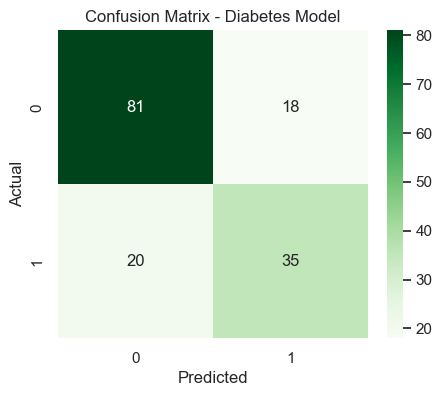

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Diabetes Model")
plt.show()

In [30]:
# ==============================
# IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")

In [33]:
# ==============================
# LOAD DATASET
# ==============================
df_kidney = pd.read_csv("kidney.csv")

# Clean column names
df_kidney.columns = df_kidney.columns.str.strip().str.lower()

df_kidney.head()

,"id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification"
0,"1,58.0,86.0,1.005,1.0,5.0,abnormal,abnormal,no..."
1,"2,71.0,146.0,1.005,0.0,5.0,Abnormal,abnormal,,..."
2,"3,48.0,96.0,1.005,,1.0,abnormal,abnormal,notpr..."
3,"4,,112.0,1.025,2.0,3.0,normal,abnormal,notpres..."
4,"5,,127.0,,,1.0, abnormal,abnormal,notpresent,n..."


In [34]:
# ==============================
# DATA UNDERSTANDING
# ==============================

print("Shape:", df_kidney.shape)

Shape: (400, 1)


In [33]:
print("\nInfo:")
print(df_kidney.info())


Info:
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    str    
 7   pc              335 non-null    str    
 8   pcc             396 non-null    str    
 9   ba              396 non-null    str    
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    str    
 17  wc              295 non-null    str    

In [35]:
print("\nMissing Values:")
print(df_kidney.isnull().sum())


Missing Values:
id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification    0
dtype: int64


In [36]:
print("\nStatistical Summary:")
print(df_kidney.describe())


Statistical Summary:
       id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
count                                                 400                                                      
unique                                                400                                                      
top     1,58.0,86.0,1.005,1.0,5.0,abnormal,abnormal,no...                                                      
freq                                                    1                                                      


In [38]:
# ==============================
# CLEAN TARGET SAFELY
# ==============================

# Fix malformed single-column load if needed
if "classification" not in df_kidney.columns and df_kidney.shape[1] == 1:
    first_col = df_kidney.columns[0]
    df_kidney = df_kidney[first_col].astype(str).str.split(",", expand=True)
    df_kidney.columns = [c.strip().lower() for c in first_col.split(",")]

# Normalize column names
df_kidney.columns = df_kidney.columns.astype(str).str.strip().str.lower()

if "classification" not in df_kidney.columns:
    raise KeyError(
        "classification column not found in df_kidney after loading the dataset."
    )

# Convert to string first (safe)
df_kidney["classification"] = (
    df_kidney["classification"].astype(str).str.strip().str.lower()
)

# Map values
df_kidney["classification"] = df_kidney["classification"].map(
    {"ckd": 1, "notckd": 0, "not ckd": 0, "1": 1, "0": 0}
)

# Drop rows where mapping failed
df_kidney = df_kidney.dropna(subset=["classification"])

# Convert to numeric safely
for col in df_kidney.columns:
    if col != "classification":
        df_kidney[col] = pd.to_numeric(df_kidney[col], errors="coerce")

# Fill missing values
df_kidney.fillna(df_kidney.median(numeric_only=True), inplace=True)

# Remove duplicates
df_kidney = df_kidney.drop_duplicates()
df_kidney = df_kidney.dropna(axis=1, how="all")
df_kidney.fillna(df_kidney.median(numeric_only=True), inplace=True)

# Remove columns with only one unique value
for col in df_kidney.columns:
    if df_kidney[col].nunique() <= 1:
        df_kidney.drop(col, axis=1, inplace=True)

In [39]:
# ==============================
# DATA PREPARATION
# ==============================

X = df_kidney.drop("classification", axis=1)
y = df_kidney["classification"]

# Convert categorical → numeric
X = pd.get_dummies(X, drop_first=True)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

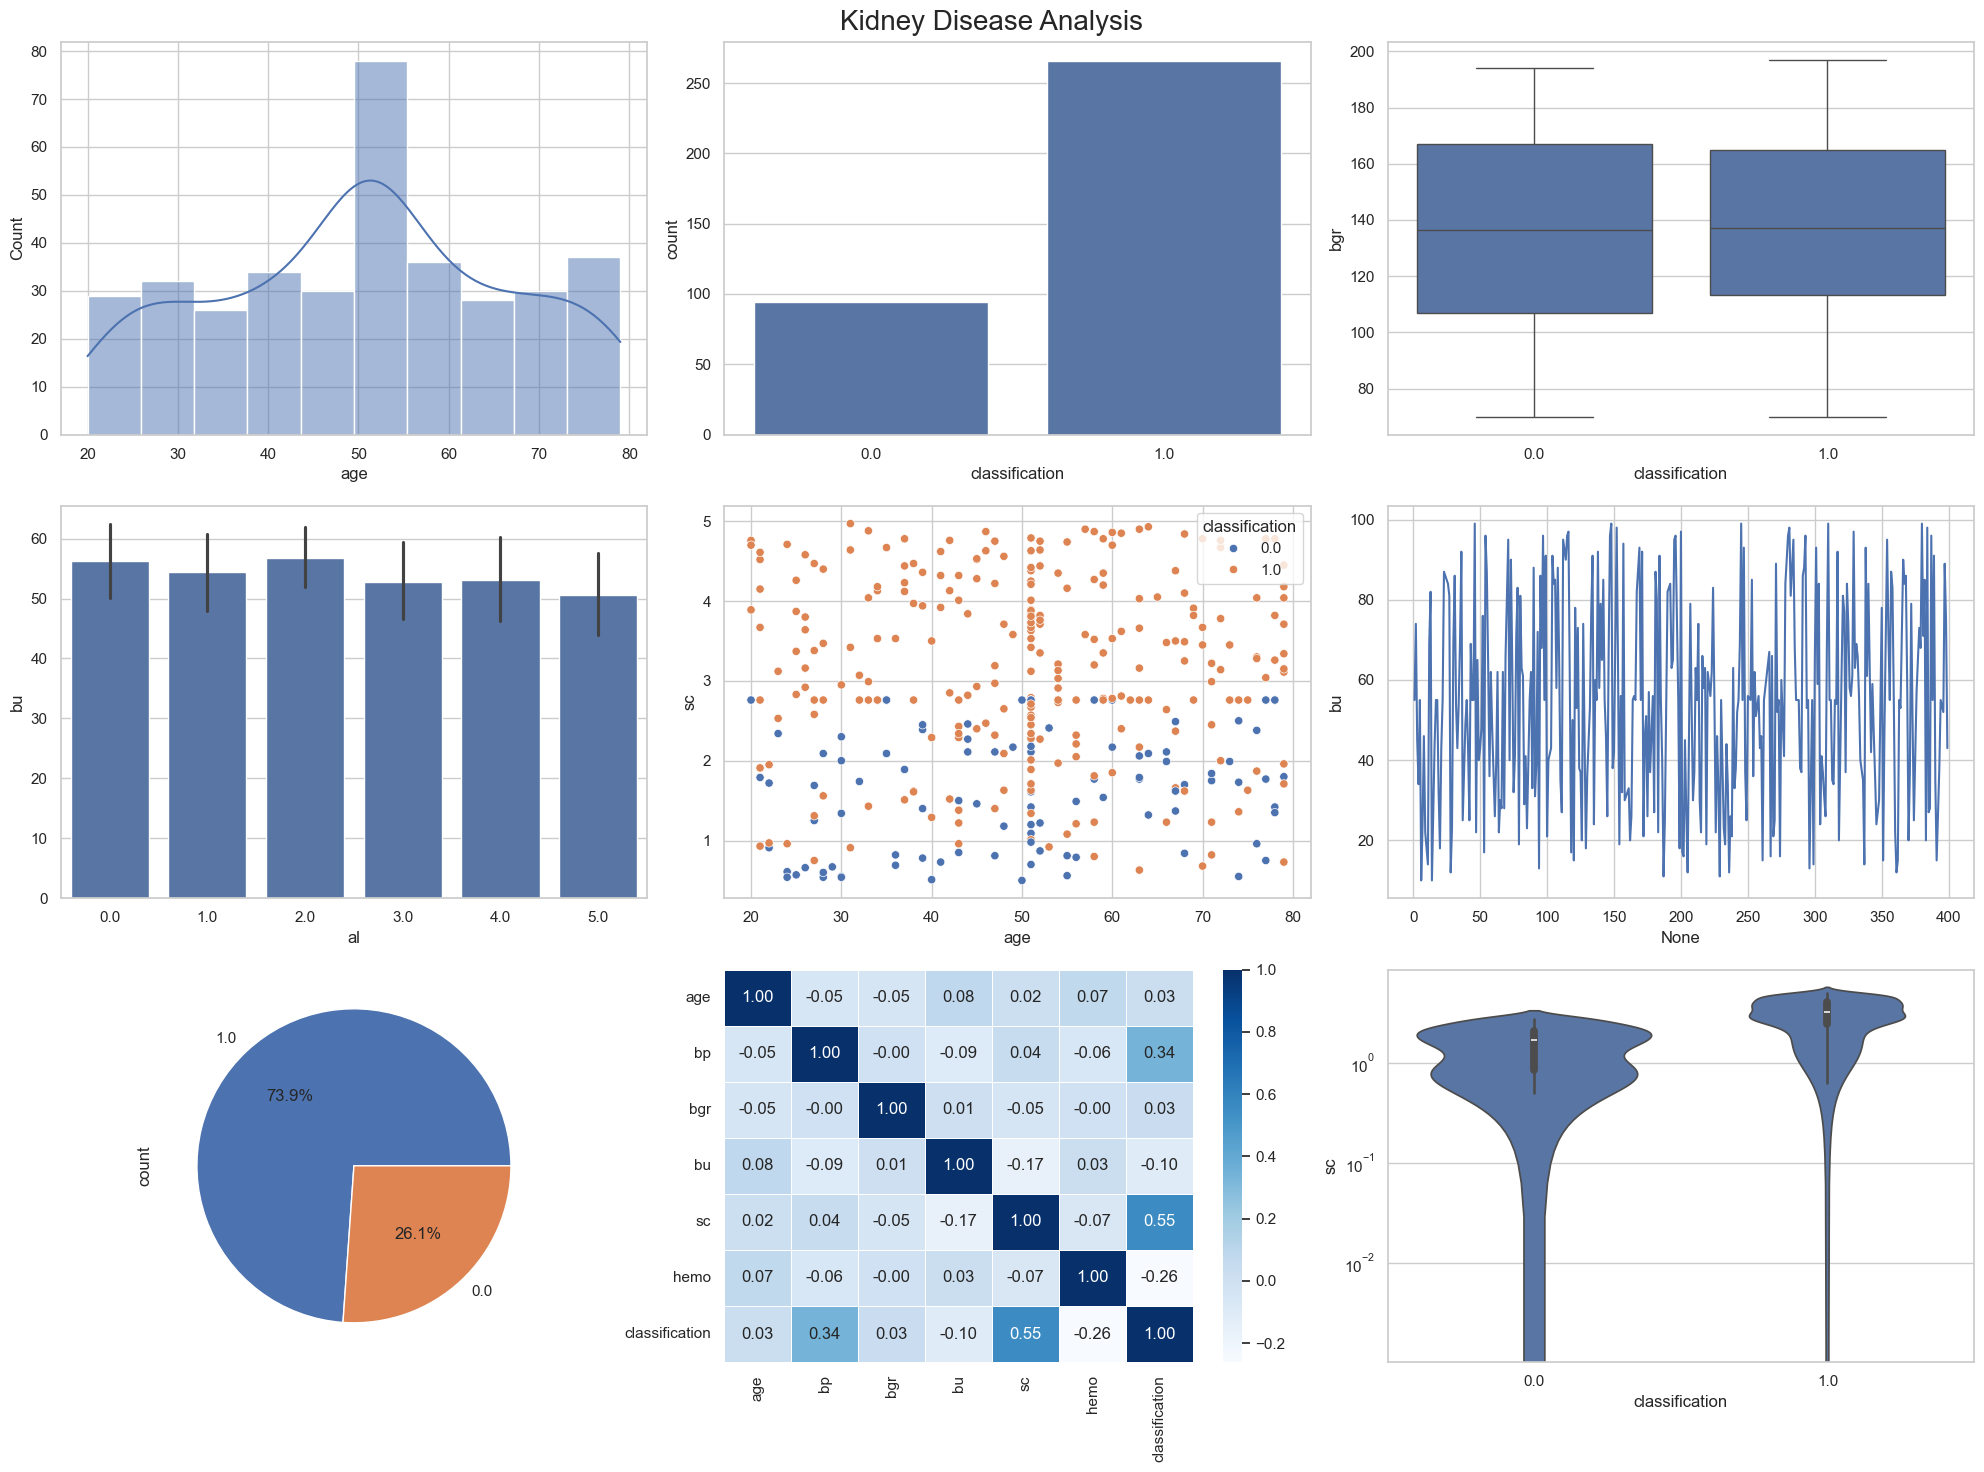

In [40]:
plt.figure(figsize=(20, 15))
plt.suptitle("Kidney Disease Analysis", fontsize=20)

# 1. Histogram
plt.subplot(3, 3, 1)
sns.histplot(df_kidney["age"], kde=True)

# 2. Countplot
plt.subplot(3, 3, 2)
sns.countplot(x="classification", data=df_kidney)

# 3. Boxplot
plt.subplot(3, 3, 3)
sns.boxplot(x="classification", y="bgr", data=df_kidney)

# 4. Barplot
plt.subplot(3, 3, 4)
sns.barplot(x="al", y="bu", data=df_kidney)

# 5. Scatterplot
plt.subplot(3, 3, 5)
sns.scatterplot(x="age", y="sc", hue="classification", data=df_kidney)

# 6. Lineplot
plt.subplot(3, 3, 6)
sns.lineplot(x=df_kidney.index, y="bu", data=df_kidney)

# 7. Pie Chart
plt.subplot(3, 3, 7)
df_kidney["classification"].value_counts().plot.pie(autopct="%1.1f%%")

# 8. Heatmap
plt.subplot(3, 3, 8)
cols = ["age", "bp", "bgr", "bu", "sc", "hemo", "classification"]
sns.heatmap(df_kidney[cols].corr(), annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)

# 9. Violin Plot
plt.subplot(3, 3, 9)
sns.violinplot(x="classification", y="sc", data=df_kidney)
plt.yscale("log")

plt.tight_layout()
plt.show()

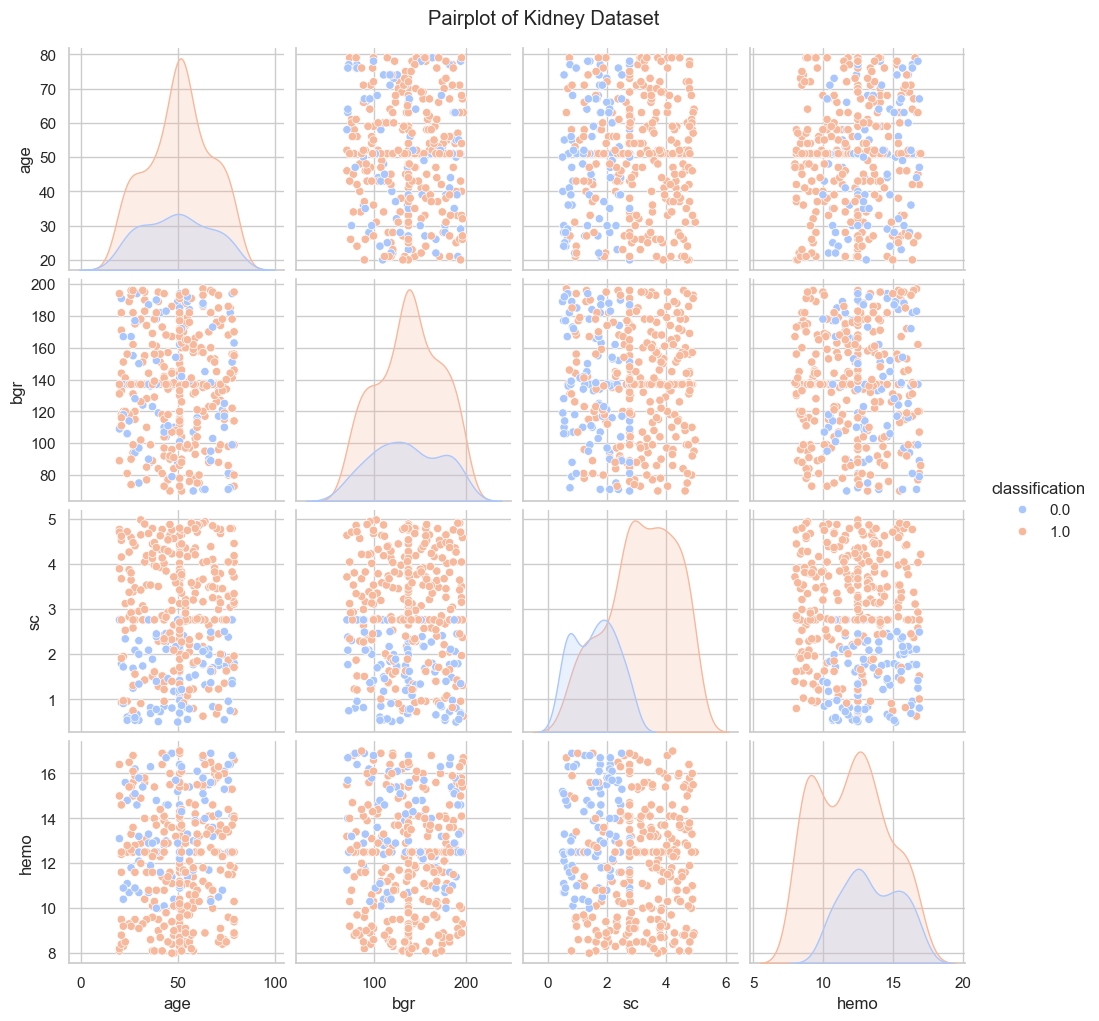

In [41]:
# ==============================
# EXTRA VISUALIZATION - PAIRPLOT
# ==============================

sns.pairplot(
    df_kidney[["age", "bgr", "sc", "hemo", "classification"]],
    hue="classification",
    palette="coolwarm",
)

plt.suptitle("Pairplot of Kidney Dataset", y=1.02)
plt.show()

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd
import numpy as np

# Feature Selection
X = df_kidney[["age", "bp", "bgr", "bu", "sc", "hemo"]]
y = df_kidney["classification"]

# Split (using strong features)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 🔹 Logistic Regression
lr_kidney = LogisticRegression(max_iter=3000)
lr_kidney.fit(X_train, y_train)

y_pred_lr = lr_kidney.predict(X_test)

joblib.dump(lr_kidney, "kidney_model.pkl")

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8055555555555556


In [43]:
# 🔹 Random Forest
rf = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42  # prevents overfitting
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))

Logistic Regression: 0.8055555555555556
Random Forest Accuracy: 0.8888888888888888


In [44]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       0.71      0.71      0.71        24
         1.0       0.85      0.85      0.85        48

    accuracy                           0.81        72
   macro avg       0.78      0.78      0.78        72
weighted avg       0.81      0.81      0.81        72



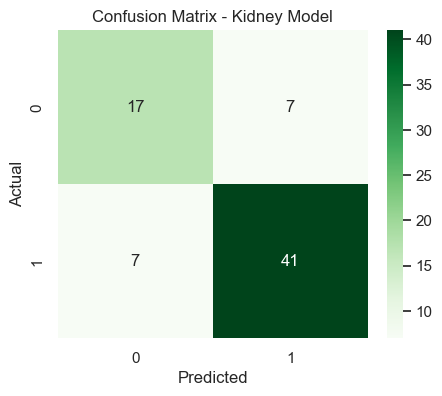

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Kidney Model")
plt.show()

In [46]:
import joblib

lr_heart = joblib.load("heart_model.pkl")
lr_diabetes = joblib.load("diabetes_model.pkl")
lr_kidney = joblib.load("kidney_model.pkl")

In [47]:
heart_feature_names = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "feature14",
    "feature15",
    "feature16",
    "feature17",
    "feature18",
    "feature19",
    "feature20",
    "feature21",
    "feature22",
]

diabetes_feature_names = [
    "pregnancies",
    "glucose",
    "bp",
    "skin",
    "insulin",
    "bmi",
    "dpf",
    "age",
]

kidney_feature_names = [
    "age",
    "bp",
    "sg",
    "al",
    "su",
    "rbc",
    "pc",
    "pcc",
    "ba",
    "bgr",
    "bu",
    "sc",
    "sod",
    "pot",
]

In [48]:
import numpy as np
import pandas as pd


def predict_all_diseases(report, heart_model, diabetes_model, kidney_model):
    """
    report: dict of patient lab data
    heart_model, diabetes_model, kidney_model: loaded sklearn models
    """

    # Get feature names each model expects
    heart_features = heart_model.feature_names_in_
    diabetes_features = diabetes_model.feature_names_in_
    kidney_features = kidney_model.feature_names_in_

    # Helper to extract features from report; fill missing with 0
    def extract_features(features):
        return pd.DataFrame([[report.get(f, 0) for f in features]], columns=features)

    # Prepare inputs as DataFrames to avoid warnings
    heart_input = extract_features(heart_features)
    diabetes_input = extract_features(diabetes_features)
    kidney_input = extract_features(kidney_features)

    # Probabilities
    heart_prob = heart_model.predict_proba(heart_input)[0][1]  # probability of disease
    diabetes_prob = diabetes_model.predict_proba(diabetes_input)[0][1]
    kidney_prob = kidney_model.predict_proba(kidney_input)[0][1]

    # Class prediction based on 0.5 threshold
    heart_pred = "Yes" if heart_prob > 0.5 else "No"
    diabetes_pred = "Yes" if diabetes_prob > 0.5 else "No"
    kidney_pred = "Yes" if kidney_prob > 0.5 else "No"

    # Return dictionary with probabilities
    return {
        "Heart Disease": {"Prediction": heart_pred, "Probability": heart_prob},
        "Diabetes": {"Prediction": diabetes_pred, "Probability": diabetes_prob},
        "Kidney Disease": {"Prediction": kidney_pred, "Probability": kidney_prob},
    }

In [50]:
patient_reports = [
    {  # Patient 1
        "age": 55,
        "sex": 1,
        "cp": 3,
        "trestbps": 140,
        "chol": 240,
        "fbs": 0,
        "restecg": 1,
        "thalach": 150,
        "exang": 0,
        "oldpeak": 1.2,
        "slope": 2,
        "ca": 0,
        "thal": 2,
        "glucose": 130,
        "bp": 80,
        "bmi": 30,
        "dpf": 0.6,
        "sg": 1.020,
        "al": 1,
        "su": 0,
        "rbc": 1,
        "pc": 0,
        "pcc": 0,
        "ba": 0,
        "bgr": 95,
        "bu": 1.2,
        "sc": 1.1,
        "sod": 136,
        "pot": 4.5,
    },
    {  # Patient 2
        "age": 62,
        "sex": 0,
        "cp": 2,
        "trestbps": 130,
        "chol": 250,
        "fbs": 1,
        "restecg": 0,
        "thalach": 145,
        "exang": 1,
        "oldpeak": 1.0,
        "slope": 2,
        "ca": 1,
        "thal": 3,
        "glucose": 110,
        "bp": 85,
        "bmi": 28,
        "dpf": 0.5,
        "sg": 1.015,
        "al": 1,
        "su": 0,
        "rbc": 1,
        "pc": 0,
        "pcc": 0,
        "ba": 0,
        "bgr": 100,
        "bu": 0.9,
        "sc": 0.9,
        "sod": 138,
        "pot": 4.0,
    },
    {  # Patient 3 (high heart & kidney risk)
        "age": 65,
        "sex": 1,
        "cp": 4,
        "trestbps": 180,
        "chol": 300,
        "fbs": 0,
        "restecg": 1,
        "thalach": 100,
        "exang": 1,
        "oldpeak": 3.0,
        "slope": 3,
        "ca": 2,
        "thal": 3,
        "glucose": 95,
        "bp": 70,
        "bmi": 24,
        "dpf": 0.2,
        "sg": 1.030,
        "al": 2,
        "su": 1,
        "rbc": 1,
        "pc": 1,
        "pcc": 1,
        "ba": 0,
        "bgr": 85,
        "bu": 2.5,
        "sc": 1.8,
        "sod": 130,
        "pot": 5.2,
    },
]
from termcolor import colored

all_results = []

# Run predictions for each patient
for report in patient_reports:
    result = predict_all_diseases(report, lr_heart, lr_diabetes, lr_kidney)
    all_results.append(result)

# Display nicely with colored risk
for i, result in enumerate(all_results, 1):
    print(f"\n--- Patient {i} Dashboard ---")
    for disease, data in result.items():
        risk = data["Probability"]
        color = "red" if risk > 0.5 else "green"
        print(
            f"{disease}: {data['Prediction']} ({colored(f'Risk: {risk*100:.1f}%', color)})"
        )


--- Patient 1 Dashboard ---
Heart Disease: Yes (Risk: 57.3%)
Diabetes: Yes (Risk: 57.6%)
Kidney Disease: Yes (Risk: 50.2%)

--- Patient 2 Dashboard ---
Heart Disease: Yes (Risk: 65.0%)
Diabetes: No (Risk: 41.4%)
Kidney Disease: Yes (Risk: 51.5%)

--- Patient 3 Dashboard ---
Heart Disease: Yes (Risk: 52.2%)
Diabetes: No (Risk: 23.4%)
Kidney Disease: Yes (Risk: 70.1%)
